In [1]:
# ============================================================
# Notebook setup
# ============================================================
%load_ext autoreload
%autoreload 2

# Retrain or use existing models
use_cached_weights=True

# Control figure size
figsize=(14, 3.5)
figsize_narrow=(14, 2.5)

import numpy as np
from util import util
import warnings
warnings.filterwarnings("ignore", ".*Consider increasing the value of the `num_workers` argument.*")
warnings.filterwarnings("ignore", ".*GPU available but not used.*")
warnings.filterwarnings("ignore", ".*Previous log files in this directory will be deleted when the new ones are saved!.*")
warnings.filterwarnings("ignore", ".*Checkpoint directory.*exists and is not empty.*")

# BB Differentiation via SFGE

## The Elephant in the Room

**So far, so good, but how to we make the _black-box_ $g(z, y)$ differentiable?**

There are a few alternatives, all with PROs and CONs:

* [This approach](https://ojs.aaai.org/index.php/AAAI/article/view/25513/25285) handles parameters in the problem constraints
  - It is based on the idea of differencing the recourse action
  - ...But it is (mostly) restricted to 1D packing problems
* [This other approach](http://proceedings.mlr.press/v139/paulus21a/paulus21a.pdf) can be used for 2s-SOP with a stretch
  - It based on idea of embedding a MILP solver in ML
  - ...But it's semantic does not fully align with 2s-SOP
* [A third approach](https://proceedings.neurips.cc/paper_files/paper/2023/file/2e14be0332c04c76742710e417cedb2a-Paper-Conference.pdf) is also MILP based
  - ...And specifically requires to access to the LP relaxation
* [This approach](https://ojs.aaai.org/index.php/AAAI/article/download/29410/30662) suggests using convex surrogates
  - Those are trained offline and very easy to optimize
  - ...But they may lead to stronly suboptimal solutions

**Here, we will see a different technique**

## Looking Back at SPO

**Let's look again at the regret loss for our original toy example** 

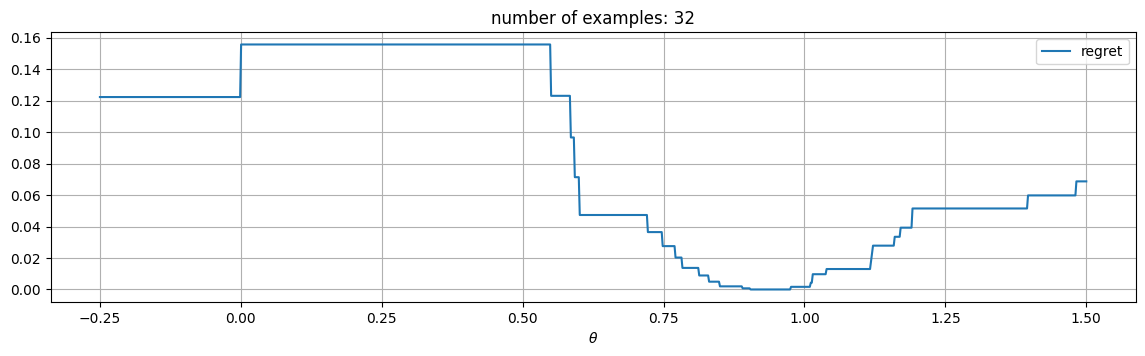

In [2]:
util.draw_loss_landscape(losses=[util.RegretLoss()], model=1, seed=42, batch_size=32, figsize=figsize)

* It is non-differentiable at places, and flat almost everywhere
* Can we think of another way to address these issues?

## Looking Back at SPO

**If we could act on this function itself, a simple solution would be _smoothing_** 

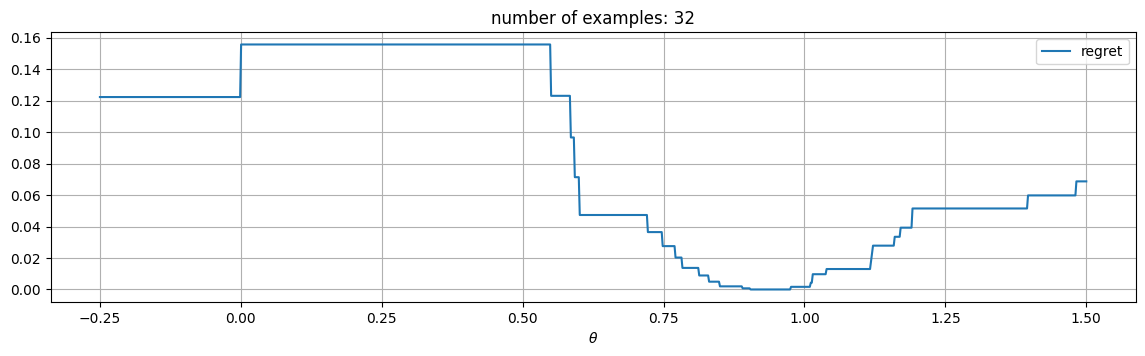

In [3]:
util.draw_loss_landscape(losses=[util.RegretLoss()], model=1, seed=42, batch_size=32, figsize=figsize)

* We could think of computing a convolution with a Gaussian kernel
* It would be like applying a Gaussian filter to an image

## Stochastic Smoothing

**But how can we do it through an optimization problem?**

A viable approach is using _stochastic smoothing_

* Rather than learning a point estimator, i.e. $\hat{y} = h(x; \theta)$
* We learn a _stochastic estimator_, i.e. $\tilde{y} \sim \mathcal{N}(h(x; \theta), \sigma)$

**Intuitively:**

* We still use a point estimator, but to predict _a vector of means_
* Then we sample $\tilde{y}$ from a normal distribution having the specified mean
* ...And a fixed standard deviation

We end up smoothing over $\hat{y}$ rather than over $\theta$

**But it's very close to what we wanted to do!**

## Stochastic Smoothing

**Let's see how it works on our toy example**

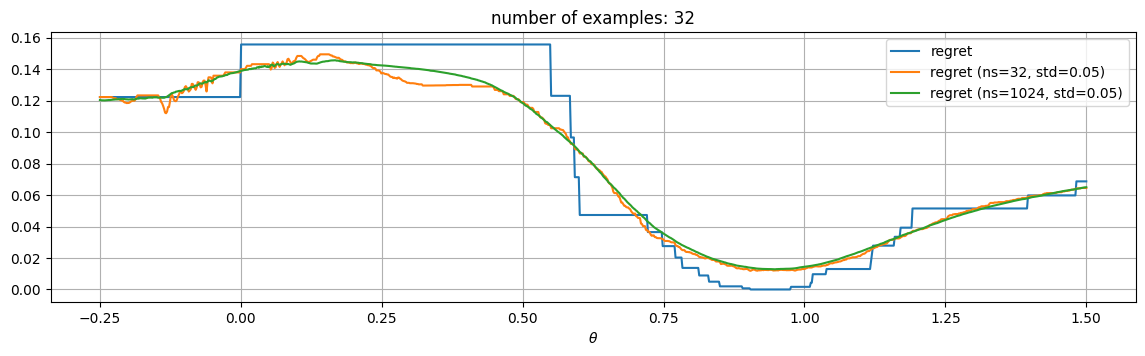

In [4]:
util.draw_loss_landscape(losses=[util.RegretLoss(), util.RegretLoss(smoothing_samples=32, smoothing_std=0.05), util.RegretLoss(smoothing_samples=1024, smoothing_std=0.05)], model=1, seed=42, batch_size=32, figsize=figsize)

* It's a stochastic approach, some some noise is to be expected
* Using _more samples_ leads to better smoothing

## Stochastic Smoothing

**We can control the smoothing level by adjusting $\sigma$**

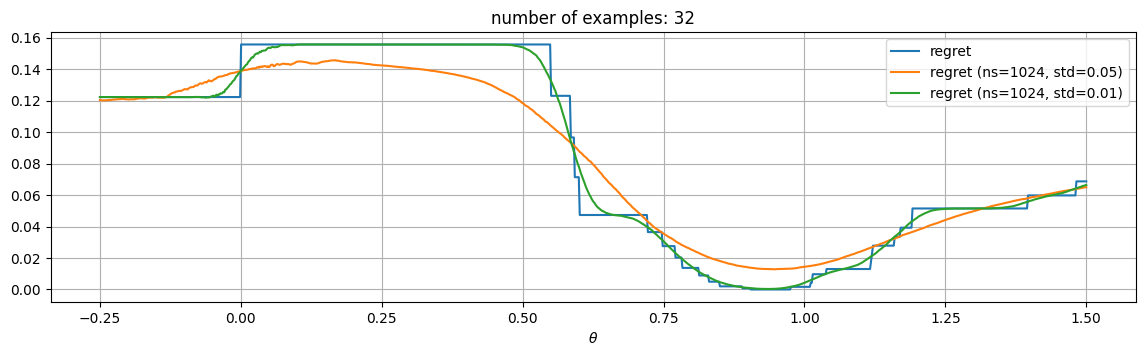

In [5]:
util.draw_loss_landscape(losses=[util.RegretLoss(), util.RegretLoss(smoothing_samples=1024, smoothing_std=0.05), util.RegretLoss(smoothing_samples=1024, smoothing_std=0.01)], model=1, seed=42, batch_size=32, figsize=figsize)

* Larger $\sigma$ value remove flat sections better
* ...But also cause _a shift_ in the position of the optimum

## Score Function Gradient Estimation

**How does that help us?**

Normally, the DFL loss looks like this:

$$
L_{DFL}(\theta) = \mathbb{E}_{(x, y) \sim P(X, Y)}[\text{regret}(y, \hat{y})]
$$

When we apply stochastic smoothing, it turns into:

$$
\tilde{L}_{DFL}(\theta) = \mathbb{E}_{(x, y) \sim P(X, Y), \tilde{y} \sim \mathcal{N}(h(x; \theta))}[\text{regret}(y, \tilde{y})]
$$

**The expectation is now computed on $x$, $y$, _and $\tilde{y}$_**

* We can use a sample average to handle the expectation on $x$ and $y$
* ...But if we do it on $\tilde{y}$ we are left with nothing differentiable

## Score Function Gradient Estimation

**So we expand the last expectation on $\tilde{y}$:**

$$
\tilde{L}_{DFL}(\theta) = \mathbb{E}_{(x, y) \sim P(X, Y)}\left[\int_{\tilde{y}} \text{regret}(y, \tilde{y}) p(\tilde{y}, \theta) d\tilde{y} \right]
$$

* $\text{regret}(y, \tilde{y})$ cannot be differentiated, since $\tilde{y}$ is a fixed sample in this setup
* However, the probability $p(\tilde{y}, \theta)$ can! It's just a Normal PDF

Now, we just need a way to handle the integral

**We do it by _focusing on the gradient_**

Due to linearity (and a few other assumptions), this is given by:

$$
\nabla \tilde{L}_{DFL}(\theta) = \mathbb{E}_{(x, y) \sim P(X, Y)}\left[\int_{\tilde{y}} \text{regret}(y, \tilde{y}) \nabla_\theta p(\tilde{y}, \theta) d\tilde{y} \right]
$$

## Score Function Gradient Estimation

**Let's consider again the expression we have obtained**

$$
\nabla \tilde{L}_{DFL}(\theta) = \mathbb{E}_{(x, y) \sim P(X, Y)}\left[\int_{\tilde{y}} \text{regret}(y, \tilde{y}) \nabla_\theta p(\tilde{y}, \theta) d\tilde{y} \right]
$$

Since that $\log'(f(x)) = 1/x f'(x)$, we can rewrite the formula as:

$$
\nabla \tilde{L}_{DFL}(\theta) = \mathbb{E}_{(x, y) \sim P(X, Y)}\left[\int_{\tilde{y}} \text{regret}(y, \tilde{y}) {\color{red}p(\tilde{y}, \theta)\nabla_\theta \log p(\tilde{y}, \theta)}d\tilde{y} \right]
$$

Now, the integral is again an expectation, so we have:

$$
\nabla \tilde{L}_{DFL}(\theta) = \mathbb{E}_{(x, y) \sim P(X, Y), \tilde{y} \sim \mathcal{N}(h(x, \theta), \sigma)}\left[\text{regret}(y, \tilde{y}) \nabla_\theta \log p(\tilde{y}, \theta) \right]
$$

## Score Function Gradient Estimation

**Finally, we can use a sample average to approximate both expectations:**

$$
\nabla \tilde{L}_{DFL}(\theta) \simeq \frac{1}{m} \sum_{i=1}^m \frac{1}{N} \sum_{k=1}^N \text{regret}(y, \tilde{y}) \nabla_\theta \log p(\tilde{y}, \theta)
$$

* For every training example we sample $\tilde{y}$ from the stochastic estimator
* We compute $\text{regret}(y, \tilde{y})$ as usual
* ...And we obtain a gradient since $p(\tilde{y}, \theta)$ is easily differentiable in $\theta$

**We can trick a tensor engine into doing the calculation by using this loss:**

$$
\tilde{L}_{DFL}(\theta) \simeq \frac{1}{m} \sum_{i=1}^m \frac{1}{N} \sum_{k=1}^N \text{regret}(y_i, \tilde{y}) \log p(\tilde{y}, \theta)
$$

## Score Function Gradient Estimation

**This approach is also know as Score Function Gradient Estimation (SFGE)**

* SFGE is the basis of the classic REINFORCE algorithm from RL
* We applied it to DFL in [a paper recently accepted at JAIR](https://arxiv.org/pdf/2307.05213)
* The closest in the differentiable optimization literature is probably [this work](https://proceedings.neurips.cc/paper_files/paper/2020/file/6bb56208f672af0dd65451f869fedfd9-Paper.pdf)

**It works with any function, not just regret**

...And in practice it can be improved by standardizing the gradient terms:

$$
\nabla \tilde{L}_{DFL}(\theta) \simeq \frac{1}{m} \sum_{i=1}^m \frac{1}{N} \sum_{k=1}^N \frac{\text{regret}(\tilde{y}_k, y_i) - \text{mean}(\text{regret}(\tilde{\bf y}, {\bf y}))}{\text{std}(\text{regret}(\tilde{\bf y}, {\bf y}))} \nabla  \log p(\tilde{y}_k, \theta)
$$

* This equivalent to treating the average as a RL baseline
* The resulting quantity is known in RL as _advantage_

## A Practical Example

**We test this on our supply planning problem**

We start by generaring a dataset of _contract values_ (the costs are fixed)

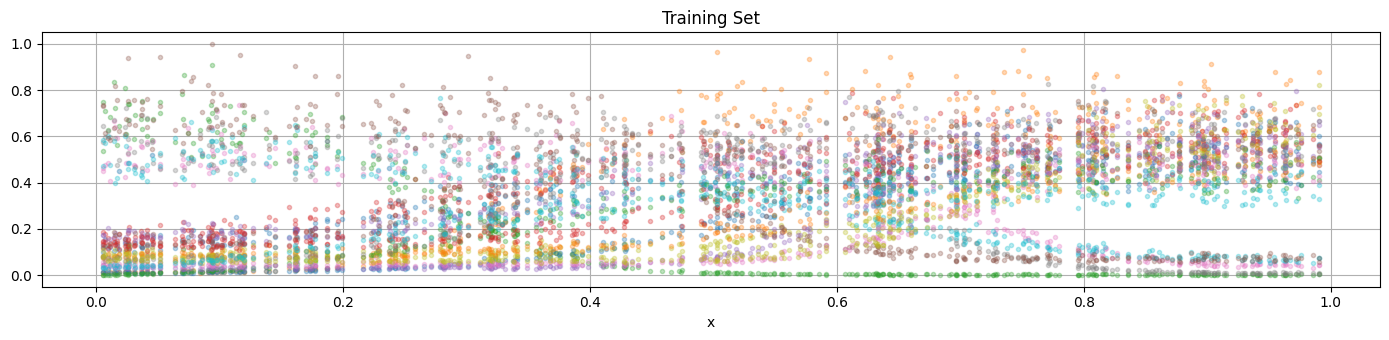

In [6]:
seed, nitems = 42, 20
data_tr = util.generate_costs(nsamples=350, nitems=nitems, seed=seed, noise_scale=.2, noise_type='rayleigh', noise_scale_type='relative')
util.plot_df_cols(data_tr, figsize=figsize, title='Training Set', scatter=True)

The distribution is the same we used for the one-stage problem

## A Practical Example

**Then we generate the remaining problem parameters**

In [7]:
# Generate the problem
rel_req = 0.6
rel_buffer_cost = 10
prb = util.generate_2s_problem(nitems, requirement=rel_req * data_tr.mean().sum(), rel_buffer_cost=rel_buffer_cost, seed=seed)
prb

ProductionProblem2Stage(costs=[1.14981605 1.38028572 1.29279758 1.23946339 1.06240746 1.06239781
 1.02323344 1.34647046 1.240446   1.28322903 1.0082338  1.38796394
 1.33297706 1.08493564 1.07272999 1.0733618  1.1216969  1.20990257
 1.17277801 1.11649166], requirement=3.865639408050176, buffer_cost=11.830809153591137)

* The minimum value if 60% of the sum of average values on the training data
* Buying in the second stage is 10 times more expensive then the average cost

## A Practical Example

**For testing, we generate multiple samples per instance**

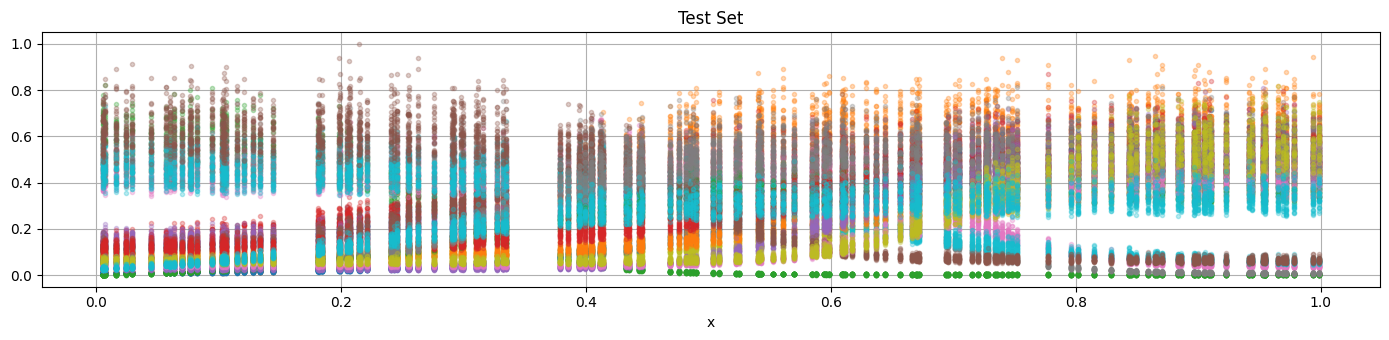

In [8]:
data_ts = util.generate_costs(nsamples=150, nitems=nitems, seed=seed, sampling_seed=seed+1, noise_scale=0.2, noise_type='rayleigh', noise_scale_type='relative', nsamples_per_point=30)
util.plot_df_cols(data_ts, figsize=figsize, title='Test Set', scatter=True)

By doing this, we get a more reliable evaluation of uncertainty

## Scalability Difference

**Since the test data contains multiple samples per input value**

...We can use it for some scalability tests

* First, let's check the run-time for using all available scenarios for each problem

In [9]:
%%time
for xv in np.unique(data_ts.index):
    prb.solve(values=data_ts[data_ts.index == xv].values)

CPU times: user 13.9 s, sys: 1.53 s, total: 15.5 s
Wall time: 15.5 s


* Then, let's see the run-time using a single sample per problem

In [10]:
%%time
for xv in np.unique(data_ts.index):
    prb.solve(values=data_ts[data_ts.index == xv].values[0, :])

CPU times: user 439 ms, sys: 91 ms, total: 531 ms
Wall time: 530 ms


* This use case is very simple, but the difference is already very noticeable
* DLF inference scales as in the second example

## A PFL Approach

**We start by training a prediction focused approach**

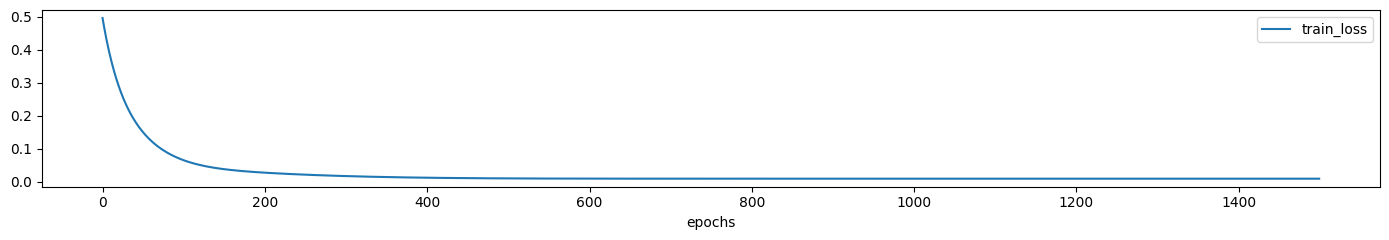

training time: 10.0386
R2: 0.784, MAE: 0.076, RMSE: 0.095 (training)
R2: 0.726, MAE: 0.076, RMSE: 0.094 (test)


In [11]:
pfl = util.TwoPhaseModel(input_size=1, output_size=nitems, hidden_sizes=[], name='pfl_2s')
pfl, history, metadata = util.train_ml_model(pfl, data_tr.index.values.reshape(-1, 1), data_tr.values, epochs=1500, load_cached=use_cached_weights, enable_progress_bar=False, accelerator='cpu')
util.plot_training_history(history, metadata=metadata, figsize=figsize_narrow, print_scores=False)
util.print_ml_metrics(pfl, data_tr.index.values.reshape(-1, 1), data_tr.values, label='training')
util.print_ml_metrics(pfl, data_ts.index.values.reshape(-1, 1), data_ts.values, label='test')

This is as fast at inference time as DFL, and can be used for warm-starting

## Evaluating Two-Stage Approaches

**Two-state stochastic approaches can be evaluated in two ways**

We can compare then with _the best we could do_

* The cost different is the proper regret
* Its computation requires solving a 2s-SOP with high accuracy
* ...Making it a very computationally expensive metric

We can compare them with the expected cost of _a clairvoyant approach_

* This is the post-hoc regret / value of perfect information we mentioned
* Its average is called _Expected Value of Perfect Information_
* Its computation requires solving a 2s-SOP _with just a single scenario_
* ...So it's much faster, but only provide an upper bound on true regret

## Evaluating the PFL Approach

**Let's check the EVPF/Post-hoc regret for the PFL Approach**

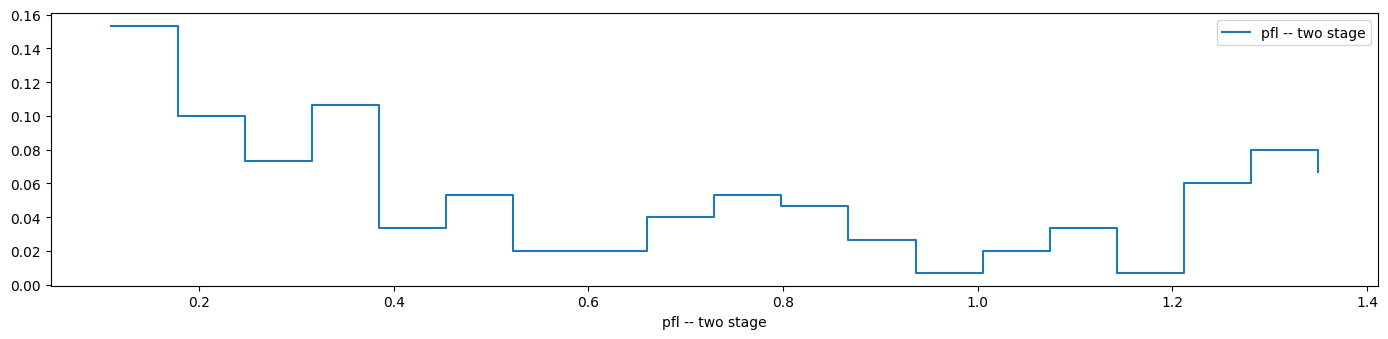

Mean: 0.640 (pfl -- two stage)


In [12]:
pfl_evpf = util.compute_evpf_2s(prb, pfl, data_ts, tlim=10)
util.plot_histogram(pfl_evpf, figsize=figsize, label='pfl -- two stage', print_mean=True);

This will be our baseline

## Training a DFL Approach

**We train a DFL model with warm starting, but no solution cache**

...Since the feasible space for the recourse actions is not fixed

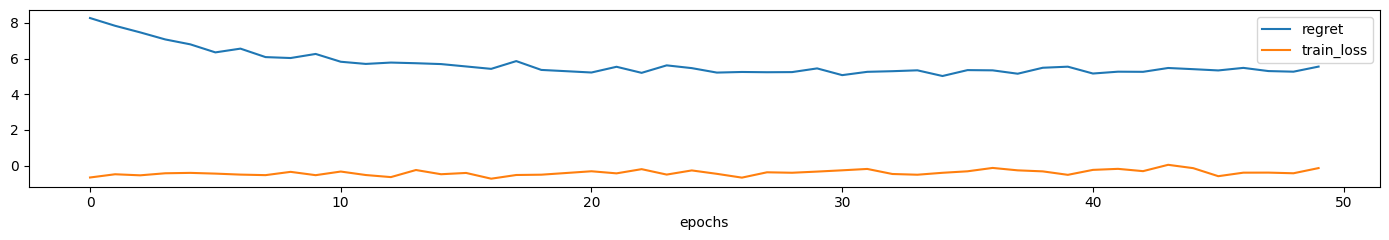

training time: 17.7454
R2: 0.626, MAE: 0.094, RMSE: 0.120 (training)
R2: 0.682, MAE: 0.079, RMSE: 0.100 (test)


In [13]:
sfge = util.DFLModel(input_size=1, output_size=nitems, hidden_sizes=[], problem=prb, name='sfge_2s', dfl_method='sfge_2s', dfl_params={'sigma': 0.1}, warm_start_state_dict=pfl.state_dict(), lr=1e-3, drop_cache_at_end=False)
sfge, history, metadata = util.train_ml_model(sfge, data_tr.index.values.reshape(-1, 1), data_tr.values, epochs=100, load_cached=use_cached_weights, enable_progress_bar=False, accelerator='cpu', batch_size=32)
util.plot_training_history(history, metadata=metadata, figsize=figsize_narrow, print_scores=False)
util.print_ml_metrics(sfge, data_tr.index.values.reshape(-1, 1), data_tr.values, label='training')
util.print_ml_metrics(sfge, data_ts.index.values.reshape(-1, 1), data_ts.values, label='test')

## Evaluating the DFL Approach

**We can now inspect the EVPF/Post-hoc regret for the DLF approach, as well**

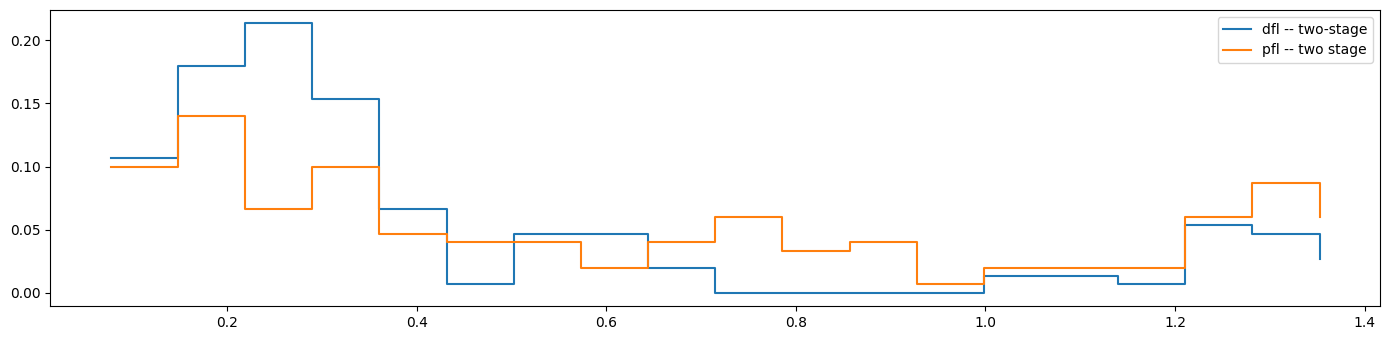

Mean: 0.449 (dfl -- two-stage), 0.640 (pfl -- two stage)


In [14]:
sfge_evpf = util.compute_evpf_2s(prb, sfge, data_ts, tlim=10)
util.plot_histogram(sfge_evpf, figsize=figsize, label='dfl -- two-stage', data2=pfl_evpf, label2='pfl -- two stage', print_mean=True);

## Using More Complex Models

**It's wort checking what happens when we switch to more complex models**

We will use a shallow network both in PFL and in DFL

In [15]:
pfl_nl = util.TwoPhaseModel(input_size=1, output_size=nitems, hidden_sizes=[16], name='pfl_2s_nl')
pfl_nl, history, metadata = util.train_ml_model(pfl_nl, data_tr.index.values.reshape(-1, 1), data_tr.values, epochs=1500, load_cached=use_cached_weights, enable_progress_bar=False, accelerator='cpu')
util.print_ml_metrics(pfl_nl, data_tr.index.values.reshape(-1, 1), data_tr.values, label='training')
util.print_ml_metrics(pfl_nl, data_ts.index.values.reshape(-1, 1), data_ts.values, label='test')

R2: 0.918, MAE: 0.041, RMSE: 0.057 (training)
R2: 0.860, MAE: 0.049, RMSE: 0.065 (test)


In [16]:
sfge_nl = util.DFLModel(input_size=1, output_size=nitems, hidden_sizes=[16], problem=prb, name='sfge_2s_nl', dfl_method='sfge_2s', dfl_params={'initial_sigma': 0.1}, warm_start_state_dict=pfl_nl.state_dict(), lr=1e-4)
sfge_nl, history, metadata = util.train_ml_model(sfge_nl, data_tr.index.values.reshape(-1, 1), data_tr.values, epochs=100, load_cached=use_cached_weights, enable_progress_bar=False, accelerator='cpu', batch_size=32)
util.print_ml_metrics(sfge_nl, data_tr.index.values.reshape(-1, 1), data_tr.values, label='training')
util.print_ml_metrics(sfge_nl, data_ts.index.values.reshape(-1, 1), data_ts.values, label='test')

R2: 0.732, MAE: 0.081, RMSE: 0.100 (training)
R2: 0.822, MAE: 0.059, RMSE: 0.074 (test)


The PFL model is still _becoming more accurate_

## Using More Complex Models

**...But the gap in terms of regret actually grows!**

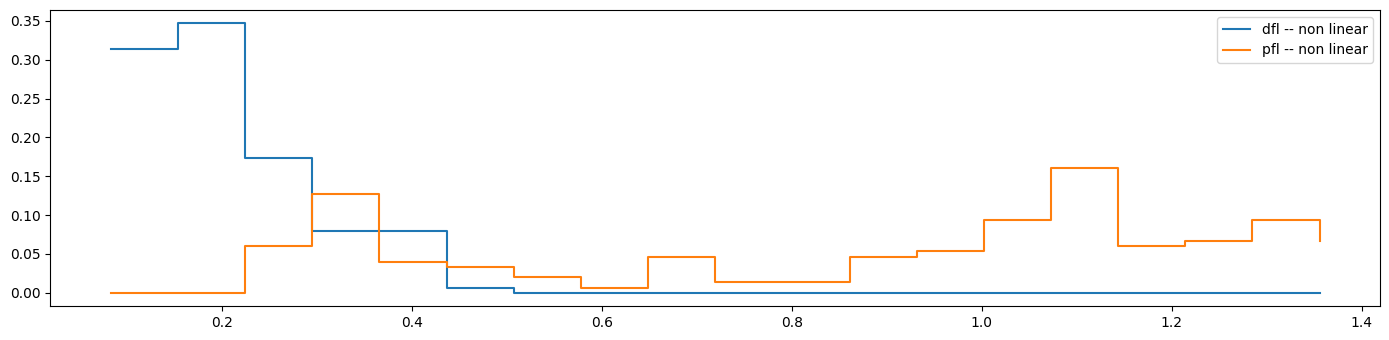

Mean: 0.208 (dfl -- non linear), 0.897 (pfl -- non linear)


In [17]:
pfl_2s_evpf_nl = util.compute_evpf_2s(prb, pfl_nl, data_ts, tlim=10)
sfge_2s_evpf_nl = util.compute_evpf_2s(prb, sfge_nl, data_ts, tlim=10)
fig = util.plot_histogram(sfge_2s_evpf_nl, figsize=figsize, label='dfl -- non linear', data2=pfl_2s_evpf_nl, label2='pfl -- non linear', print_mean=True)